<div dir="rtl" style="direction: rtl; text-align: right;">

# هفته ۱۲ — تمرین کلاسی: گزارش Transfer Learning برای GreenLoop

> **مشتری:** شرکت GreenLoop Recycling Corp. یک مرکز بازیابی مواد دارد و می‌خواهد روی خط تفکیک، یک دوربین قرار دهد تا اشیا را در کلاس‌های
> `cardboard`، `glass`، `metal`، `paper`، `plastic` و `trash` دسته‌بندی کند. آن‌ها سه محدودیت برای تیم PixelWorks AI (تیم شما) تعیین کرده‌اند که در تمام این جلسه مهم هستند:
>
> 1. **یک دوربین کوچک روی خط، نه یک GPU در data center.** هر راهکاری که پیشنهاد می‌دهید باید بتواند روی سخت‌افزار نسبتاً محدود train شود و در نهایت اجرا شود.
> 2. **چند صد تصویر label‌شده، نه چند صد هزار تصویر.** تهیه‌ی label بیشتر ممکن است، اما هزینه دارد؛ هر مجموعه‌ی اضافه از تصاویر label‌شده بخشی از زمان یک تکنسین را می‌گیرد.
> 3. **هزینه‌ی همه‌ی خطاها یکسان نیست.** اگر یک شیء `metal` اشتباهاً به مسیر `glass` فرستاده شود، ممکن است crusher گیر کند. اما اشتباه گرفتن `paper` با `cardboard` اهمیت بسیار کمتری دارد.
>
> خروجی نهایی شما در پایان این جلسه یک **decision memo** کوتاه است: واقعاً پیشنهاد می‌کنید GreenLoop کدام مدل را deploy کند و چرا؟
> تمام کارهای دیگر امروز، شواهدی هستند که برای نوشتن صادقانه‌ی این memo لازم دارید.

## نمای کلی جلسه

- **مدت زمان:** حدود ۳ ساعت برای مسیر اصلی؛ Part 5.5 یک bonus اختیاری است و اگر گروه زودتر تمام کرد می‌توانید انجامش دهید.
- **فرمت:** . هر ساعت نقش‌ها را عوض کنید: **Driver** (کد را تایپ می‌کند)، **Auditor** (هر عدد را مستقل دوباره بررسی می‌کند تا گروه آن را بپذیرد)، و **Recorder** (پاسخ‌های گروه را می‌نویسد و هم‌زمان فهرست شواهد لازم برای memo نهایی را نگه می‌دارد؛ در Part 6 به کارتان می‌آید).
- **Dataset:** همان TrashNet واقعی که در lecture بارگذاری شد؛ `ImageFolder` در مسیر `data/trashnet/`، شش کلاس، با split طبقه‌بندی‌شده‌ی 80/10/10. Dataset جدیدی لازم نیست آماده کنید.
- تعداد سؤال‌ها کمتر از تمرین‌های قبلی است، اما هر سؤال مهم است و پاسخ آن بعداً دوباره استفاده می‌شود. رد کردن یک سؤال فقط امتیاز همان سؤال را کم نمی‌کند؛ بخشی از شواهد لازم برای memo را هم از دست می‌دهید.

## چهار مدلی که تا پایان درباره‌شان نظر خواهید داشت

| مدل | توضیح |
|---|---|
| **Employee A / B** | ResNet18 با random weights در برابر pretrained ResNet18 — فقط یک warm-up، نه یک experiment کامل |
| **Experiment C** | backbone فریز شده و فقط یک classifier head جدید |
| **Experiment D** | ادامه‌ی Experiment C؛ `layer4` باز شده و learning rate کوچک‌تری دارد |

حالا شروع کنید به ساختن پرونده‌ی شواهد.

</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 0 — آماده‌سازی (داده شده، ≈۱۰ دقیقه)

این دقیقاً همان pipeline دو جلسه‌ی lecture است و چیز جدیدی ندارد.
دیتاست (TrashNet واقعی، حدود ۴۳ مگابایت) اولین بار که این بخش را اجرا کنید، در صورت نبودن روی دیسک، به‌صورت خودکار دانلود می‌شود — نیازی به آماده‌سازی دستی نیست. آن را اجرا کنید، بررسی کنید class list و اندازه‌ی splitها درست به نظر می‌رسند، و ادامه دهید.

</div>


In [1]:
from copy import deepcopy

from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from tensorflow.python.keras import Sequential
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import ResNet18_Weights, resnet18
from sklearn.model_selection import train_test_split

SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = Path("data")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False

set_seed()
print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
# دانلود یک‌باره: دیتاست واقعی TrashNet (ریپازیتوری garythung/trashnet در گیت‌هاب،
# حدود ۴۳ مگابایت، ۲٬۵۲۷ عکس واقعی در ۶ کلاس بالا). اگر مدرس شما از قبل
# data/trashnet/ را آماده کرده باشد، این سلول آن را تشخیص می‌دهد و کاری انجام نمی‌دهد.
set_seed()
import shutil
import urllib.request
import zipfile

EXPECTED_CLASSES_FOR_DOWNLOAD = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

if not (DATA_ROOT.exists() and sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()) == EXPECTED_CLASSES_FOR_DOWNLOAD):
    print("TrashNet در سیستم پیدا نشد -- در حال دانلود (حدود ۴۳ مگابایت، یک‌بار)...")
    zip_path = Path("data/_trashnet_dataset-resized.zip")
    zip_path.parent.mkdir(parents=True, exist_ok=True)
    url = "https://raw.githubusercontent.com/garythung/trashnet/master/data/dataset-resized.zip"
    urllib.request.urlretrieve(url, zip_path)

    extract_dir = Path("data/_trashnet_extract")
    with zipfile.ZipFile(zip_path) as zip_file:
        zip_file.extractall(extract_dir)

    if DATA_ROOT.exists():
        shutil.rmtree(DATA_ROOT)
    shutil.move(str(extract_dir / "dataset-resized"), str(DATA_ROOT))
    shutil.rmtree(extract_dir, ignore_errors=True)
    zip_path.unlink()
    print("انجام شد. TrashNet آماده است در", DATA_ROOT)
else:
    print("TrashNet از قبل موجود است در", DATA_ROOT)

TrashNet از قبل موجود است در data


In [3]:
weights = ResNet18_Weights.DEFAULT
evaluation_transform = weights.transforms()

set_seed()

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

deterministic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

full_train_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=train_transform)

full_eval_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=deterministic_transform)

EXPECTED_CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
assert full_train_dataset.classes == EXPECTED_CLASSES
class_names = full_train_dataset.classes

all_indices = np.arange(len(full_train_dataset))
all_targets = np.asarray(full_train_dataset.targets)

train_indices, temp_indices = train_test_split(
    all_indices, test_size=0.20, random_state=SEED, stratify=all_targets,
)
val_indices, test_indices = train_test_split(
    temp_indices, test_size=0.50, random_state=SEED, stratify=all_targets[temp_indices],
)

train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices.tolist())

val_dataset = torch.utils.data.Subset(full_eval_dataset, val_indices.tolist())

test_dataset = torch.utils.data.Subset(full_eval_dataset, test_indices.tolist())


def make_loader(dataset, shuffle, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(dataset, batch_size=32, shuffle=shuffle, num_workers=0, generator=generator)


train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset, shuffle=False)
# test_loader stays sealed -- not built today, same discipline as the lecture.

print("Classes:", class_names)
print("Train:", len(train_dataset), "| Val:", len(val_dataset), "| Test (sealed):", len(test_dataset))



Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train: 2021 | Val: 253 | Test (sealed): 253


In [4]:
def set_model_mode(model, is_training):
    '''Given (from Session 2): puts the model in the right mode for a fixed
    feature extractor OR a partial fine-tune, keeping BatchNorm running
    statistics locked at their pretrained values either way.'''
    set_seed()
    if not is_training:
        model.eval()
        return
    model.train()
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()


def run_epoch(model, loader, loss_fn, optimizer=None):
    is_training = optimizer is not None
    set_model_mode(model, is_training)
    model.to(DEVICE)
    total_loss, total_correct, total_examples = 0.0, 0, 0
    with torch.set_grad_enabled(is_training):

        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, labels)
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size

    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}


def fit_model(model, train_loader, val_loader, optimizer, epochs):
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}

    best_val_loss = float("inf")
    best_state = deepcopy(model.state_dict())
    best_epoch = 0
    start_time = time.perf_counter()

    for epoch in range(epochs):
        train_metrics = run_epoch(model, train_loader, loss_fn, optimizer=optimizer)

        val_metrics = run_epoch(model, val_loader, loss_fn)

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | train acc: {train_metrics['accuracy']:.1%} | "
            f"val acc: {val_metrics['accuracy']:.1%} | val loss: {val_metrics['loss']:.3f}"
        )

    model.load_state_dict(best_state)
    return model, history, best_epoch, time.perf_counter() - start_time


def denormalize_imagenet(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return image_tensor.cpu() * std + mean


print("Training utilities ready.")

Training utilities ready.


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 0.5 — سؤال مصاحبه (≈۱۰ دقیقه)

مثال ابتدای جلسه را به خاطر بیاورید: Employee A یعنی ResNet18 با random weights و Employee B یعنی pretrained ResNet18؛ هر دو برای پروژه‌ی خط تفکیک بررسی می‌شوند.

**Q0.1:** فقط اجازه دارید **یک** سؤال در مصاحبه بپرسید؛ سؤالی که واقعاً بتوانید در پنج دقیقه‌ی آینده با کد اجرا کنید تا قبل از اینکه هیچ‌کدام استخدام (train) شوند، تفاوت اصلی بین این دو candidate مشخص شود. سؤال شما چیست، و چه نتیجه‌ای نشان می‌دهد Employee B چیزی دارد که Employee A ندارد؟

> **پاسخ گروه:**
<div dir= rtl>کدام مدل نیاز دارد بینایی را یاد بگیرد و کدام مدل نیاز دارد که صرفا کلاس ها را یاد گرفته و نتیجه را پیش بینی کند
</div>
</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 0.7 — شرط‌بندی روی Transfer Learning (≈۱۰ دقیقه)

قبل از دست زدن به کد، مفهوم اصلی را دقیق روشن کنید، چون تمام کار امروز بر پایه‌ی آن است.

**واقعاً چه چیزی داخل pretrained weights در ResNet18 ذخیره شده است؟** یک پوشه از عکس‌های حفظ‌شده‌ی ImageNet نیست؛ بلکه detectorهای عددی‌ای هستند که برای پاسخ دادن به الگوهای بصری مفید تنظیم شده‌اند و تقریباً ساختاری سلسله‌مراتبی دارند: لایه‌های ابتدایی edgeها و تفاوت‌های رنگی را می‌گیرند، لایه‌های میانی textureها و اجزای اشیا را، و لایه‌های پایانی ترکیب‌های خاص‌تر مربوط به source task را. **Transfer learning یک شرط‌بندی است** روی اینکه بخشی از این hierarchy — که کاملاً از 1.2 میلیون تصویر *ImageNet* یاد گرفته شده — هنوز برای شش دسته‌ی زباله‌ی GreenLoop مفید باشد، حتی با اینکه هیچ labelای در ImageNet با نام "cardboard" وجود ندارد.

**Q0.7.1 (اول پیش‌بینی کنید، بعد دفاع کنید):** GreenLoop یک target task است. حالا یک task دوم و بسیار متفاوت را در نظر بگیرید: دسته‌بندی **chest X-ray** به گروه‌های تشخیصی. برای *هرکدام* از این دو target task پیش‌بینی کنید که featureهای pretrained روی ImageNet احتمالاً **خوب** transfer می‌شوند یا **ضعیف**، و با ویژگی‌های بصری مشخص توضیح دهید چرا؛ فقط نگویید «تصاویر پزشکی فرق دارند». مشخص کنید کدام ویژگی‌های عکس‌های طبیعی RGB مثل edge، color، texture یا شکل معمول اشیا، در تصاویر grayscale X-ray و در تصاویر زباله قابل استفاده هستند یا نیستند. سپس مستقیم پاسخ دهید: اگر پیش‌بینی شما اشتباه باشد، در کدام‌یک از این دو task پیامد مهم‌تری دارد و چرا؟

> **پاسخ گروه:**
<div dir=rtl>در هر دو حالت استفاده بهتر است ولی تصاویر ایمیج نت رنگی هستند که در این حالت برای مسئله ای که تصاویر رنگی دارد بهتر است.تصاویر پزشکی تک کاناله هستند تصاویر green loop نیازی به اگمنتیشن ندارند</div>
</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 1 — قرارداد Preprocessing (≈۲۰ دقیقه)

هر مجموعه از pretrained weights با یک **قرارداد ضمنی** train شده است:
*"ورودی را دقیقاً با همین روش آماده کن تا filterهای من همان رفتاری را داشته باشند که مستند شده است."*
اگر قرارداد را بشکنید، مدل همچنان اجرا می‌شود، اما خروجی آن دیگر معنی قابل اتکایی ندارد.

## نمونه‌ی نقض قرارداد

یکی از هم‌تیمی‌ها در PixelWorks این snippet را برای شما می‌فرستد و می‌گوید چون «بدون error اجرا می‌شود» پس مشکلی ندارد:

```python
breach_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

sample_image, _ = untransformed_dataset[0]
input_tensor = breach_transform(sample_image).unsqueeze(0).to(DEVICE)

with torch.inference_mode():
    probabilities = pretrained_model(input_tensor).softmax(dim=1)[0]
```

**Q1.1 (بند قرارداد را مشخص کنید، بعد ثابت کنید اصلاح شده):** دقیقاً کدام «بند» از قرارداد preprocessing توسط `breach_transform` نقض شده است؟ برای استناد به مقدار درست، باید به کدام object واقعی که بالاتر در notebook load شده مراجعه کنید؟ فقط نگویید «اعداد اشتباه‌اند». بعد از اصلاح، چه **شاهد مشخصی** به یک هم‌تیمی شکاک نشان می‌دهید تا ثابت کنید قرارداد واقعاً restore شده، نه اینکه فقط چند عدد عوض شده باشد؟

> **پاسخ گروه:**
از آمار های میانگین و واریانس مربوط به دیتاست IMAGENET استفاده نکرده است
>
**TODO:** pretrained model را load کنید و نسخه‌ی اصلاح‌شده را خودتان اجرا کنید.

</div>


In [5]:
# TODO: weights = ResNet18_Weights.DEFAULT
set_seed()
weights = ResNet18_Weights.DEFAULT

# TODO: pretrained_model = resnet18(weights=weights).to(DEVICE)
pretrained_model = resnet18(weights=weights).to(DEVICE)

# TODO: pretrained_model.eval()
pretrained_model.eval()

# TODO: imagenet_categories = weights.meta["categories"]
imagenet_categories = weights.meta["categories"]

# print(len(imagenet_categories))
# TODO: untransformed_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=None)
untransformed_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=None)

# TODO: sample_image, target_index = untransformed_dataset[0]
sample_image, target_index = untransformed_dataset[0]

print(f"target_index: {target_index}")

# TODO: sample_target = untransformed_dataset.classes[target_index]
sample_target = untransformed_dataset.classes[target_index]
print(f"sample_target: {sample_target}")

# TODO: input_tensor = evaluation_transform(sample_image).unsqueeze(0).to(DEVICE)
input_tensor = evaluation_transform(sample_image).unsqueeze(0).to(DEVICE)
# H *  W
# B * H * W
# TODO: with torch.inference_mode():
with torch.inference_mode():
#           probabilities = pretrained_model(input_tensor).softmax(dim=1)[0]
    probabilities = pretrained_model(input_tensor).softmax(dim=1)[0]
    print(f"probabilities: {len(probabilities)}")

# TODO: top_probabilities, top_indices = probabilities.topk(5)
    top_probabilities, top_indices = probabilities.topk(5)
    print("top_probabilities:", top_probabilities)
    print("top_indices:", top_indices)
    for index,proba in zip(top_indices,top_probabilities):
        print(f"imagenet_categories[index]: {imagenet_categories[index]} ==> {proba}")

# TODO: print the TrashNet ground-truth label, then the top-5 ImageNet guesses with their probabilities

target_index: 0
sample_target: cardboard
probabilities: 1000
top_probabilities: tensor([0.2812, 0.2069, 0.0572, 0.0494, 0.0405])
top_indices: tensor([549, 478, 556, 434, 591])
imagenet_categories[index]: envelope ==> 0.28116679191589355
imagenet_categories[index]: carton ==> 0.2068888247013092
imagenet_categories[index]: fire screen ==> 0.05723597854375839
imagenet_categories[index]: bath towel ==> 0.04943393915891647
imagenet_categories[index]: handkerchief ==> 0.04053998365998268


<div dir="rtl" style="direction: rtl; text-align: right;">

## اولین متن مصاحبه

شما از Employee B (یعنی pretrained model) خواسته‌اید یک تصویر واقعی از GreenLoop را فقط با vocabulary هزارکلمه‌ای ImageNet که از قبل می‌شناسد توصیف کند؛ قبل از اینکه چیزی درباره‌ی `cardboard`، `glass`، `metal`، `paper`، `plastic` یا `trash` یاد گرفته باشد.

**Q1.2 (تفسیر کنید، نمره ندهید):** هیچ‌کدام از top-5 حدس‌های Employee B قرار نیست دقیقاً درست باشند؛ ImageNet کلاسی به نام «plastic bottle cap» در دسته‌بندی زباله ندارد. این طبیعی است و failure محسوب نمی‌شود. **یک حدس مشخص** از output واقعی خودتان نقل کنید و توضیح دهید این حدس درباره‌ی meaningful بودن visual representation مدل نسبت به random بودن آن چه چیزی نشان می‌دهد. جداگانه، یک مورد را نام ببرید که این transcript به‌تنهایی **هنوز نمی‌تواند** درباره‌ی موفقیت Employee B در کار تفکیک به شما بگوید.

> **پاسخ گروه:**
خروجی مد نظر ما 6 کلاسه هست و نه 1000 کلاسه
</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 2 — Freeze Audit (≈۲۵ دقیقه)

هر parameter مدل را مثل یک حساب در دفتر مالی در نظر بگیرید. "Frozen" یعنی حسابی که در آن **هیچ پولی (gradient) اجازه‌ی جابه‌جایی ندارد**. قبل از اینکه GreenLoop اجازه دهد چیزی train شود، وظیفه‌ی شما به‌عنوان Auditor این است که ثابت کنید دفتر حساب‌ها دقیقاً balance است؛ نه اینکه فقط ظاهری آن را نگاه کنید.

## ساختار حساب‌ها را بسازید

**TODO:** کل backbone را freeze کنید، سپس classifier head را برای شش کلاس زباله‌ی ما جایگزین کنید.

</div>


In [6]:
# TODO: feature_model = resnet18(weights=weights)
set_seed()
feature_model = resnet18(weights=weights)



# TODO: freeze every parameter in feature_model
feature_model.eval()
for param in feature_model.parameters():
    param.requires_grad = False

# TODO: num_features = feature_model.fc.in_features
num_features = feature_model.fc.in_features
print(num_features)

# TODO: feature_model.fc = nn.Linear(num_features, len(class_names))
feature_model.fc = nn.Linear(num_features, len(class_names))


# TODO: feature_model = feature_model.to(DEVICE)
feature_model = feature_model.to(DEVICE)

print("New classifier:", feature_model.fc)

512
New classifier: Linear(in_features=512, out_features=6, bias=True)


<div dir="rtl" style="direction: rtl; text-align: right;">

## دو Audit، نه یکی

**Q2.1 (قبل از Audit پیش‌بینی کنید):** فرض کنید یک هم‌تیمی با اطمینان می‌گوید backbone را درست freeze کرده است. قبل از اجرای کد، **دو راه جداگانه** نام ببرید که این ادعا می‌تواند بی‌سروصدا غلط باشد، حتی اگر عبارت `for p in model.parameters(): p.requires_grad = False` در کدش وجود داشته باشد. راهنما: یکی به این مربوط است که head نسبت به freeze loop *چه زمانی* جایگزین شده، و دیگری به اتفاقی مربوط است که به‌محض شروع training رخ می‌دهد و به `requires_grad` محدود نیست.

> **پاسخ گروه:**

model.eval() ممکن است استفاده نکرده باشد.
ممکن است که head قبل از requires_grad=False تعریف شده باشد

**TODO — Audit 1 (parameter ledger):** optimizer را بسازید و با استفاده از `id()` در Python، نه `==`، ثابت کنید که **تمام** parameterهای trainable را **دقیقاً یک‌بار** شامل می‌شود؛ نه بیشتر و نه کمتر.

</div>


In [7]:
head_optimizer = torch.optim.Adam(feature_model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
set_seed()
# torch.optim.SGD(feature_model.fc.parameters(), lr=1e-3) #SGD
# torch.optim.SGD(feature_model.fc.parameters(), lr=1e-3, momentum=0.9) #momentom
# torch.optim.AdamW(feature_model.fc.parameters(), lr=1e-3, weight_decay=1e-4) #AdamW

# head_optimizer.step() #use Gradient to updata parameters


# TODO: optimizer_ids = the set of id() for every parameter tensor inside
#       head_optimizer.param_groups[0]["params"]
# TODO: expected_ids = the set of id() for every parameter in feature_model
#       where parameter.requires_grad is True
# TODO: assert optimizer_ids == expected_ids

optimizer_ids = {
    id(param) for param in head_optimizer.param_groups[0]["params"]
}
print("optim",optimizer_ids)

expected_ids = {
    id(param) for param in feature_model.fc.parameters() if param.requires_grad
}
print("expected",expected_ids)

assert optimizer_ids == expected_ids, (
    "Optimizer parameters do not match the trainable model parameters."
)
print("The ledger balances: the optimizer holds exactly the trainable parameters, no more, no less.")

optim {1867564387136, 1867564400096}
expected {1867564387136, 1867564400096}
The ledger balances: the optimizer holds exactly the trainable parameters, no more, no less.


<div dir="rtl" style="direction: rtl; text-align: right;">

**TODO — Audit 2 (شرط دو امضا):** یک forward pass و backward pass در training mode اجرا کنید، سپس بررسی کنید هر دو شرط برای backbone و head برقرار هستند.

</div>


In [8]:
set_seed()
images, labels = next(iter(train_loader))

images, labels = images.to(DEVICE), labels.to(DEVICE)
# TODO: put feature_model in eval mode, then feature_model.fc specifically in train mode
feature_model.eval()

for param in feature_model.parameters():
    param.requires_grad = False

feature_model.fc.train()

for param in feature_model.fc.parameters():
    param.requires_grad = True

# TODO: logits = feature_model(images)
logits = feature_model(images)

# TODO: loss = nn.CrossEntropyLoss()(logits, labels)
criterion = nn.CrossEntropyLoss()

loss = criterion(logits, labels)
# TODO: feature_model.zero_grad(); loss.backward()
feature_model.zero_grad()
loss.backward()

print("Backbone requires_grad:", feature_model.conv1.weight.requires_grad)
print("Backbone .grad is None:", feature_model.conv1.weight.grad is None)

print("Head requires_grad:", feature_model.fc.weight.requires_grad)
print("Head .grad is None:", feature_model.fc.weight.grad is None)

Backbone requires_grad: False
Backbone .grad is None: True
Head requires_grad: True
Head .grad is None: False


E:\Maktab-145\maktab_kernel\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: The detected GPU (Intel(R) UHD Graphics) is not officially supported by PyTorch XPU. Running workloads on this device may result in unexpected behavior.
For stable and fully supported execution, please use GPUs based on Intel Arc (Alchemist) series or newer.
Refer to the hardware prerequisites for more information: https://docs.pytorch.org/docs/main/notes/get_start_xpu.html#hardware-prerequisite (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\xpu\XPUFunctions.cpp:134.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


<div dir="rtl" style="direction: rtl; text-align: right;">

**Q2.2 (دو امضا، نه یکی):** مدیر عملیات GreenLoop که روی compliance حساس است می‌پرسد: *«اگر `requires_grad=False` از update شدن backbone جلوگیری می‌کند، چرا در زمان training باید کل مدل را در `eval()` mode هم نگه داریم؟ آیا این کار اضافی نیست؟»* با مثال «دو امضای جداگانه برای انتقال پول از یک حساب» پاسخ دهید: مشخص کنید هر امضا واقعاً چه چیزی را کنترل می‌کند، و یک سناریوی مشخص مربوط به نوعی layer که همین حالا در ResNet18 وجود دارد توضیح دهید که در آن داشتن فقط یکی از این دو امضا باعث می‌شود وعده‌ی "frozen" بودن بی‌سروصدا شکسته شود.

> **پاسخ گروه:**
requires_grad=False

این امضا کنترل می‌کند که آیا پارامترها اصلاً در فرایند یادگیری و update شدن شرکت کنند یا نه. وقتی برای پارامترهای backbone می‌نویسیم:

param.requires_grad = False

برای آن پارامترها gradient محاسبه نمی‌شود و optimizer نباید آن‌ها را update کند. بنابراین این امضا جلوی تغییر مستقیم وزن‌های backbone توسط optimizer را می‌گیرد.

eval()

این امضا کنترل می‌کند که خود layerها در هنگام forward با چه رفتاری اجرا شوند. eval() به معنی «وزن‌ها را freeze کن» نیست؛ بلکه بعضی layerها را از رفتار training به رفتار inference می‌برد. این موضوع برای layerهایی مثل BatchNorm در ResNet18 مهم است.
</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

## ببینید دقیقاً چه چیزی را freeze کرده‌اید

قبل از اینکه چیزی train کنید، ببینید backbone فریز‌شده واقعاً چه چیزی به classifier می‌دهد؛ نه class score، نه prediction، فقط اعداد.

**TODO:** classifier را موقتاً حذف کنید و raw representation با 512 dimension را برای چند تصویر validation بررسی کنید.

</div>


In [9]:
# TODO: backbone = nn.Sequential(*list(feature_model.children())[:-1])
set_seed()
backbone = nn.Sequential(*list(feature_model.children())[:-1])
# TODO: backbone.eval()
backbone.eval()
# TODO: images, _ = next(iter(val_loader))
image,_ = next(iter(val_loader))
# TODO: images = images[:4].to(DEVICE)
image = image.to(DEVICE)
# TODO: with torch.inference_mode():
#           feature_maps = backbone(images)
#           feature_vectors = torch.flatten(feature_maps, start_dim=1)
with torch.inference_mode():
          feature_maps = backbone(images)
          feature_vectors = torch.flatten(feature_maps, start_dim=1)

print("Feature-vector shape:", feature_vectors.shape)
print("First image, first 10 numbers:")
print(feature_vectors[0, :10])

Feature-vector shape: torch.Size([32, 512])
First image, first 10 numbers:
tensor([1.3034, 1.3149, 0.5017, 0.9716, 0.2914, 0.0645, 0.0962, 0.0195, 3.5032,
        0.9864])


<div dir="rtl" style="direction: rtl; text-align: right;">

**Q2.3:** این 512 عدد، 512 class probability **نیستند** و هرکدام به‌تنهایی هم قابل تفسیر به‌عنوان «میزان glass بودن» یا «میزان metal بودن» **نیستند**. در یک یا دو جمله توضیح دهید این اعداد واقعاً چه هستند؛ یعنی یک coordinate system برای چه نوع representationی؟ سپس در کد خودتان به **layer object دقیق** اشاره کنید — نه توضیح کلی، بلکه attribute name واقعی — که تبدیل «512 coordinate» به «6 class score» در آن انجام می‌شود.

> **پاسخ گروه:**
بعد دوم تنسور به دست آمده میانگین فیچر مپ های خارج شده از لایه 4 شبکه رزنت 18 هست که پس از عبور از adaptive average pool  به این حالت در آمده
</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 3 — Experiment C: اولین candidate برای Deployment (≈۳۵ دقیقه)

**TODO:** fixed-feature model را train کنید. برای اینکه زمان جلسه کافی باشد، تعداد epochها از lecture کامل کمتر است (۵ به‌جای ۱۰)، اما الگوی کلی باید همچنان قابل مشاهده باشد.

</div>


In [10]:
HEAD_ONLY_EPOCHS = 5
set_seed()
# TODO: feature_model, feature_history, feature_best_epoch, feature_time = fit_model(
#     feature_model, train_loader, val_loader, optimizer=head_optimizer, epochs=HEAD_ONLY_EPOCHS,
# )
feature_model, feature_history, feature_best_epoch, feature_time = fit_model(
    feature_model, train_loader, val_loader, optimizer=head_optimizer, epochs=HEAD_ONLY_EPOCHS,
)
# TODO: feature_only_model = deepcopy(feature_model).to(DEVICE)  # preserve for later comparison
feature_only_model = deepcopy(feature_model).to(DEVICE)
print(f"Best epoch: {feature_best_epoch} | training time: {feature_time:.1f}s")

Epoch 01/5 | train acc: 49.4% | val acc: 67.2% | val loss: 0.962
Epoch 02/5 | train acc: 70.2% | val acc: 75.9% | val loss: 0.773
Epoch 03/5 | train acc: 74.9% | val acc: 75.1% | val loss: 0.734
Epoch 04/5 | train acc: 76.3% | val acc: 77.5% | val loss: 0.667
Epoch 05/5 | train acc: 79.1% | val acc: 76.7% | val loss: 0.641
Best epoch: 5 | training time: 478.1s


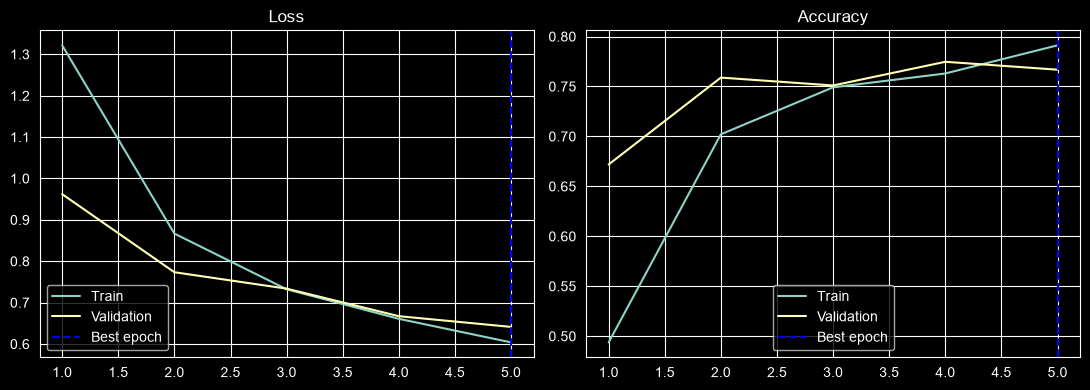

In [11]:

epochs_range = range(1, HEAD_ONLY_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_range, feature_history["train_loss"], label="Train")
axes[0].plot(epochs_range, feature_history["val_loss"], label="Validation")
axes[0].axvline(feature_best_epoch, color="Blue", linestyle="--", label="Best epoch")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(epochs_range, feature_history["train_accuracy"], label="Train")
axes[1].plot(epochs_range, feature_history["val_accuracy"], label="Validation")

axes[1].axvline(feature_best_epoch, color="Blue", linestyle="--", label="Best epoch")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

<div dir="rtl" style="direction: rtl; text-align: right;">

# ✔️ checkpoint

## نمودار را مثل Auditor بخوانید، نه مثل تماشاگر

**Q3.1 (سؤال divergence):** تابع `fit_model` برای انتخاب "best" checkpoint از **validation loss** استفاده می‌کند، نه validation accuracy. به دو panel نمودار نگاه کنید. یک بازه از epochها پیدا کنید — یا اگر در run شما واضح نیست، پیش‌بینی کنید — که validation loss و validation accuracy داستان‌های **متفاوتی** تعریف کنند؛ مثلاً یکی هنوز بهتر شود ولی دیگری plateau کند یا بدتر شود. اگر مجبور باشید در یک جمله دفاع کنید که چرا `fit_model` برای checkpoint selection به loss بیشتر از accuracy اعتماد می‌کند، چه می‌گویید؟ به این فکر کنید که loss چه چیزی را می‌بیند که شمارش گسسته‌ی درست/غلط نمی‌بیند.

> **پاسخ گروه:**
لاس میزان اطمینان و درستی لیبل رو هم زمان ارزیابی میکنه ، ولی اکیوریسی صرفا میگه درسته بوده یا غلط بوده ! بنابراین اگر با اطمینان کمی درست دسته بندی بشه نمونه ها اکیوریسی میگه خوبه ! و تغییر نداره ولی لاس افزایش پیدا میکنه .
## Incident reportها

**TODO:** دقیقاً مثل `collect_mistakes` در lecture، تعداد ۸ اشتباه validation از `feature_only_model` جمع‌آوری کنید.

</div>


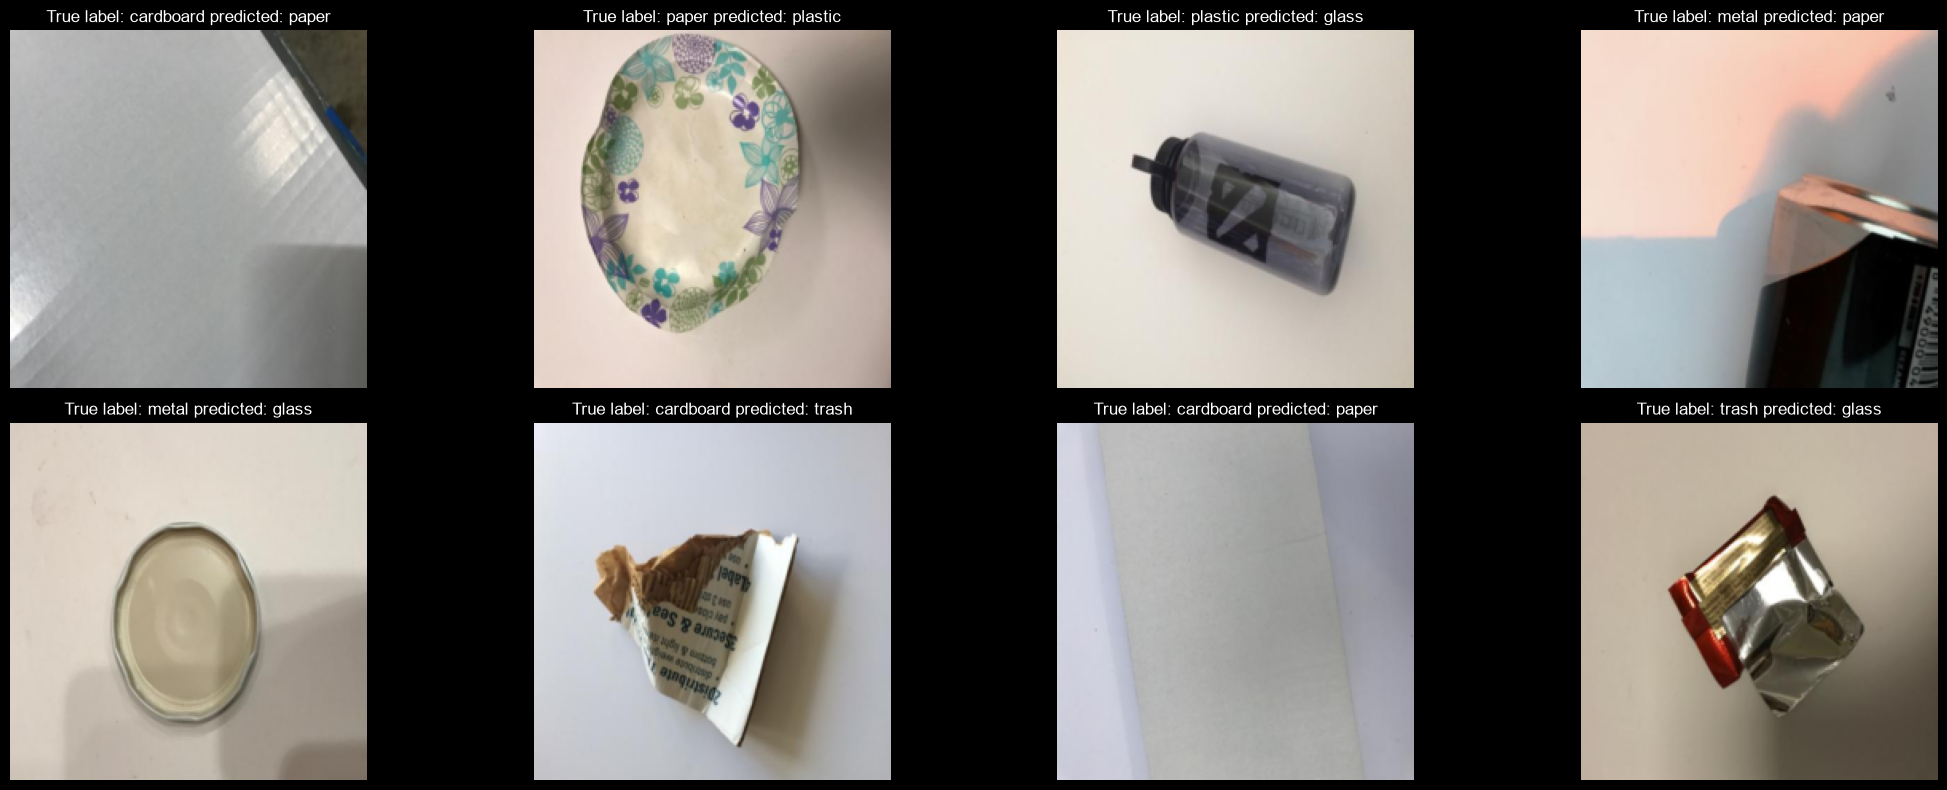

In [21]:
@torch.inference_mode()
def collect_mistakes(model, loader, limit=8):
    set_seed(SEED)
    model.eval()
    mistakes = []
    for images, labels in loader:
        predictions = model(images.to(DEVICE)).argmax(dim=1).cpu()
        for image, true_label, predicted_label in zip(images, labels, predictions):
            if true_label != predicted_label:
                mistakes.append((image, true_label.item(), predicted_label.item()))
            if len(mistakes) == limit:
                return mistakes
    return mistakes


# TODO: mistakes = collect_mistakes(feature_only_model, val_loader)
mistakes = collect_mistakes(feature_only_model, val_loader)


# TODO: plot all 8 mistakes in a 2x4 grid (denormalize_imagenet + permute + clamp),
#       with "True: {class} / Pred: {class}" as each title
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
for i, axis  in enumerate(axes.flatten()):
    image = denormalize_imagenet(mistakes[i][0]).permute(1,2,0).clamp(0,1)
    axis.imshow(image)
    axis.set_title(f"True label: {class_names[mistakes[i][1]] } predicted: {class_names[mistakes[i][2]] }")
    axis.axis("off")
    axis.grid(False)
plt.tight_layout()
plt.show()

<div dir="rtl" style="direction: rtl; text-align: right;">

**Q3.2 (incident reportها را ثبت کنید):** هرکدام از ۸ اشتباه را در **یکی** از دسته‌های زیر قرار دهید؛ این‌ها یک failure taxonomy واقعی هستند، نه جست‌وجوی bug در کد:

**(a) label ambiguity** — یک فرد منطقی ممکن است با ground truth موافق نباشد؛  
**(b) occlusion/framing** — شیء crop شده، روی اشیای دیگر قرار گرفته یا بخشی از آن پنهان است؛  
**(c) material-cue subtlety** — ممکن است اشتباه به‌خاطر سردرگمی درباره‌ی ویژگی بصری‌ای مثل transparency یا reflectiveness باشد که frozen backbone آن را خوب نمایش نمی‌دهد؛  
**(d) something else** — نوع آن را خودتان نام ببرید.

حالا تصمیم اصلی: کدام دسته در بین ۸ مورد شما بیشترین تعداد را دارد، و نتیجه بیشتر به کدام اقدام اشاره می‌کند: **"unfreeze the backbone" (موضوع جلسه‌ی امروز)**، **"get better labels"** یا **"collect more data"**؟ هرکدام از دسته‌ها می‌تواند منطقی به یکی از این سه اقدام منتهی شود؛ mapping انتخابی خودتان را با دلیل دفاع کنید.

> **پاسخ گروه:**
3 مورد از تصاویر به علت کراپ غلط در کلاس اشتباهی دسته بندی شده بودند

و 6 مورد خطای مربوط به تشخیص بافت و اشتباه گرفتن اشیاء به خاطر براق بودن و رنگ و بافت وجود داشت پس با اختلاف خطای حالت c از همه خطا ها رایج تر بود

لذا تصمیم بر این شد که لایه 4 مدل رزنت رو آموزش بدیم تا بافت تصاویر خاص این کلاس رو بهتر درک کنه
</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 3.5 — Experiment C واقعاً چه چیزی را Test می‌کند؟ (≈۸ دقیقه)

قبل از رفتن به fine-tuning، باید به سؤالی جواب دهید که memo شما باید بتواند در برابرش دفاع کند.

Experiment C نسبت به یک small CNN که from scratch train شده فقط *یک* چیز را تغییر نداده است؛ architecture عوض شده (ResNet18 در برابر small CNN)، initial weights عوض شده‌اند (pretrained در برابر random)، parameterهای trainable فرق دارند (فقط classifier در برابر همه‌ی parameterها)، و input pipeline هم فرق می‌کند (`224×224` با preprocessing شبیه ImageNet در برابر هر pipelineای که small CNN استفاده کرده است). در lecture، control experiment گمشده را **Experiment C0** می‌نامیم: ResNet18 با **random** weights، backbone فریز‌شده و فقط classifier train می‌شود؛ یعنی همان architecture و همان frozen-parameter policy مانند C، اما بدون هیچ pretrained knowledge.

**Q3.5.1 (بدون اجرا پیش‌بینی کنید):** بدون اینکه امروز زمان صرف train کردن C0 کنید، پیش‌بینی کنید validation accuracy آن به نتیجه‌ی Experiment C نزدیک‌تر می‌شود یا به یک small CNN با random weights؟ پاسخ را با تفاوت بین "architecture" و "learned weights" توجیه کنید. سپس مستقیم جواب دهید: آیا نتیجه‌ی واقعی Experiment C گروه شما به‌تنهایی ثابت می‌کند که **خود pretraining** کمک کرده، یا فقط ثابت می‌کند که «کل recipe با هر چهار تغییر هم‌زمان» بهتر بوده است؟ کدام ادعا را واقعاً می‌توانید در memo بنویسید و کدام ادعا برای پشتیبانی به C0 نیاز دارد؟

> **پاسخ گروه:**

1. ادعای اول : انتظار دارم پاسخم به مدل رزنت با وزن های آموخته شده نزدیک تر باشه ، چرا که در آزمایش c0  قرار است روی همین مدل رزنت با وزن های از پیش آموزش دیده کار کنیم و این باعث میشود فقط لایه 4 را انفریز کنیم و نتایج به همین مدل رزنت از پیش آموزش دیده فعلی به علت وزن های شروع مشابه و معماری مشابه نزدیک تر خواهد بود تا مدل simple CNN با معماری متفاوت و وزن های تصادفی
2.
</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 3.7 — طیفی که قرار است روی آن حرکت کنید (≈۱۰ دقیقه)

Fixed feature extraction (Experiment C) «تکنیک نهایی» نیست؛ فقط یک نقطه در طیفی است که مشخص می‌کند چه مقدار از pretrained knowledge اجازه دارد تغییر کند:

| Strategy | Trainable | ریسک آسیب زدن به دانش قبلی |
|---|---|---:|
| Fixed features (C) | فقط classifier | خیلی کم |
| Partial fine-tuning (امروز، D) | `layer4` + classifier | متوسط |
| Full fine-tuning | همه‌چیز | بیشتر |
| From scratch | همه‌چیز، شروع random | دانش قبلی‌ای برای محافظت وجود ندارد |

حرکت به سمت راست این طیف یک ریسک مشخص دارد:
**catastrophic forgetting** — updateهای بزرگ یا بی‌دقت می‌توانند ساختار pretrained مفید را overwrite کنند، قبل از اینکه target dataset کوچک شواهد کافی برای توجیه این تغییر به مدل بدهد. مثال lecture این بود: pretrained weights مثل یک دست‌نوشته‌ی دقیق و ارزشمند هستند؛ fine-tuning باید با مداد در حاشیه یادداشت اضافه کند، نه اینکه با ماژیک ضخیم صفحه‌ها را بازنویسی کند.

**چه چیزهایی forgetting را محتمل‌تر می‌کنند:** target dataset بسیار کوچک (⚠️ GreenLoop یکی دارد)، learning rate بزرگ، unfreeze کردن تعداد زیادی layer به‌صورت هم‌زمان، یا training بیش از حد طولانی.

**نشانه‌های هشدار اگر این اتفاق در حال رخ دادن باشد:** validation performance بلافاصله بعد از unfreezing افت می‌کند؛ training accuracy سریع بالا می‌رود در حالی که validation accuracy پایین می‌آید؛ نتایج بین epochها ناپایدار می‌شوند.

**Q3.7.1:** policy امروز — فقط `layer4` را unfreeze کنید، learning rate آن را 10× کمتر از head قرار دهید و BatchNorm را frozen نگه دارید — دقیقاً برای کاهش همین ریسک طراحی شده است. **دو** مورد از چهار risk factor بالا را نام ببرید که این policy مستقیماً در برابرشان محافظت ایجاد می‌کند و توضیح دهید *چطور* هر محافظ کار می‌کند. سپس **یک** risk factor از فهرست را نام ببرید که حتی با policy دقیق امروز همچنان در پروژه‌ی GreenLoop وجود دارد و هیچ انتخابی برای learning rate به‌تنهایی نمی‌تواند آن را حل کند.

> **پاسخ گروه:**

**Q3.7.2 (experimentهای خودتان را روی طیف قرار دهید):** با استفاده از جدول بالا، Experiment C در کدام ردیف قرار می‌گیرد و Experiment D بعد از تکمیل Part 4 در کدام ردیف خواهد بود؟ اگر در یک experiment آینده، هم `layer3` **و هم** `layer4` را unfreeze کنید و شواهد Part 5 نشان دهد این کار اشتباه بوده، باید به کدام **یک** از ردیف‌های جدول برگردید؟ چه شواهدی باید در curveها دیده شود تا این عقب‌نشینی منطقی باشد؟

> **پاسخ گروه:**
> بله شروع با وزن های تصادفی قطعا ضعیف تر از استفاده از وزن های از پیش آموزش دیده است
</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 4 — رسمی کردن وعده: Unfreeze کردن Layer 4 (≈۴۰ دقیقه)

مثال lecture را به خاطر بیاورید: pretrained weights مثل یک دست‌نوشته‌ی دقیق هستند و fine-tuning باید با مداد در حاشیه یادداشت اضافه کند، نه با ماژیک ضخیم. گفتن جمله‌ای مثل «فقط حاشیه‌های Layer 4 را تغییر می‌دهم» آسان است، اما شکستن تصادفی همین وعده هم آسان است. امروز فقط این وعده را نمی‌دهید؛ آن را **رسمی و قابل اثبات** می‌کنید: قبل از training ثبت می‌کنید دست‌نوشته چه شکلی بوده و بعد از training، صفحه‌به‌صفحه ثابت می‌کنید فقط همان بخشی که اجازه داشته تغییر کرده است.

## وعده را دقیق و قابل اندازه‌گیری کنید

**TODO:** از `feature_model` train‌شده شروع کنید، فقط `layer4` را unfreeze کنید، BatchNorm را به‌صورت صریح دوباره freeze کنید (برای اطمینان بیشتر و مطابق درس «دو امضا» در Part 2)، و دو parameter group را بسازید.

</div>


In [22]:
# TODO: feature_model.layer4.requires_grad_(True)
feature_model.layer4.requires_grad_(True)
# TODO: for every nn.BatchNorm2d module anywhere in feature_model,
#       explicitly set requires_grad_(False) again (even inside layer4)
for param in feature_model.parameters():
    if isinstance(param, nn.BatchNorm2d):
            param.eval()
# TODO: backbone_parameters = list of parameters in feature_model.layer4 where requires_grad is True
backbone_parameters = [param for  param in feature_model.layer4.parameters() if param.requires_grad ]
# TODO: head_parameters = list of parameters in feature_model.fc where requires_grad is True
head_parameters = [param for  param in feature_model.fc.parameters() if param.requires_grad ]

print("Trainable layer4 tensors:", len(backbone_parameters))
print("Trainable head tensors:", len(head_parameters))

Trainable layer4 tensors: 15
Trainable head tensors: 2


<div dir="rtl" style="direction: rtl; text-align: right;">

**Q4.1 (نسبت را توجیه کنید، سپس failure را پیش‌بینی کنید):** optimizer را با `BACKBONE_LR = 1e-4` و `HEAD_LR = 1e-3` بسازید؛ یعنی rate مربوط به head ده برابر backbone است. با استفاده از مثال ویرایش دست‌نوشته، در یک جمله توضیح دهید *چرا* این دو بخش مدل سزاوار rate متفاوت هستند. سپس یک **نشانه‌ی مشخص و قابل مشاهده** در training curveها پیش‌بینی کنید که اگر هم‌تیمی شما اشتباهاً `HEAD_LR` را برای هر دو group استفاده کند انتظار دارید ببینید. فقط نگویید «بدتر می‌شود»؛ دقیقاً curve چه رفتاری خواهد داشت و این رفتار چه تفاوتی با overfitting معمولی دارد؟

> **پاسخ گروه:**
اگر از لرنینگ ریت بزرگ برای لایه های کانولوشنی از پیش آموزش دیده مدل استفاده کنیم دچار فراموشی فاجعه بار میشویم که این باعث میشود مدل دانشی که از تصاویر ایمیج نت آموخته از یاد ببرد و مدل رفتار نوسانی خواهد داشت در نمودار
>
**TODO:** optimizer را با parameter groupها بسازید، سپس **هر دو** Audit مربوط به Part 2 را دوباره اجرا کنید؛ بعد از unfreezing هم ledger باید دقیقاً balance باشد.

</div>


In [30]:
BACKBONE_LR = 1e-4
HEAD_LR = 1e-3

# TODO: fine_tune_optimizer = torch.optim.Adam([
#     {"params": backbone_parameters, "lr": BACKBONE_LR, "name": "layer4"},
#     {"params": head_parameters, "lr": HEAD_LR, "name": "classifier"},
# ], weight_decay=1e-4)
fine_tune_optimizer = torch.optim.Adam([
    {"params": backbone_parameters, "lr": BACKBONE_LR, "name": "layer4"},
    {"params": head_parameters, "lr": HEAD_LR, "name": "classifier"},
], weight_decay=1e-4)


# TODO: re-run the id()-set ledger audit from Part 2, but now against
#       fine_tune_optimizer -- it must still balance (every trainable
#       parameter in feature_model, exactly once, no more no less)

optimizer_ids = {
    id(param)    for group in fine_tune_optimizer.param_groups    for param in group["params"]
}




trainables = nn.Sequential(
    feature_model.layer4,
    feature_model.fc,
)
expected_ids = {
    id(param)
    for param in trainables.parameters()
}

assert optimizer_ids == expected_ids, (
    "Optimizer parameters do not match the trainable model parameters."
)
print("The ledger balances: the optimizer holds exactly the trainable parameters, no more, no less.")

for index, group in enumerate(fine_tune_optimizer.param_groups):
    count = sum(p.numel() for p in group["params"])
    print(f"Group {index}: {group['name']:10s} | lr={group['lr']:.0e} | parameters={count:,}")

The ledger balances: the optimizer holds exactly the trainable parameters, no more, no less.
Group 0: layer4     | lr=1e-04 | parameters=8,393,728
Group 1: classifier | lr=1e-03 | parameters=3,078


# Checkpoint 2✔️

<div dir="rtl" style="direction: rtl; text-align: right;">

## ثبت رسمی: قبل از ویرایش، نسخه‌ی فعلی دست‌نوشته را ذخیره کنید

**Q4.2 (اول پیش‌بینی، بعد verify — دقیقاً با همین ترتیب):** قبل از اجرای cell بعدی، پیش‌بینی گروه را برای هر ردیف کامل کنید:

| Tensor | تغییر پیش‌بینی‌شده بعد از fine-tuning |
|---|---|
| `conv1` (stem) | ؟ |
| `layer3[0].conv1` | ؟ |
| `layer4[0].conv1` | ؟ |
| `fc` (classifier) | ؟ |

> **پیش‌بینی گروه (قبل از اجرای cellهای بعدی جدول بالا را کامل کنید):**

**TODO:** snapshot مربوط به "before" را ثبت کنید.

</div>


In [ ]:
# TODO: weights_before = {
#     "stem": feature_model.conv1.weight.detach().cpu().clone(),
#     "layer3": feature_model.layer3[0].conv1.weight.detach().cpu().clone(),
#     "layer4": feature_model.layer4[0].conv1.weight.detach().cpu().clone(),
#     "classifier": feature_model.fc.weight.detach().cpu().clone(),
# }
print("Snapshot recorded.")

<div dir="rtl" style="direction: rtl; text-align: right;">

**TODO:** partial fine-tuning را اجرا کنید (۵ epoch، مطابق بودجه‌ی زمانی کاهش‌یافته‌ی Part 3).

</div>


In [ ]:
FINE_TUNE_EPOCHS = 5

# TODO: feature_model, fine_history, fine_best_epoch, fine_time = fit_model(
#     feature_model, train_loader, val_loader, optimizer=fine_tune_optimizer, epochs=FINE_TUNE_EPOCHS,
# )
# TODO: fine_tuned_model = feature_model

print(f"Best fine-tuning epoch: {fine_best_epoch} | training time: {fine_time:.1f}s")

<div dir="rtl" style="direction: rtl; text-align: right;">

**TODO:** مقدارهای "before" و "after" را مقایسه کنید؛ آیا دست‌نوشته دقیقاً همان جایی که اجازه داده بودید تغییر کرده و هیچ جای دیگری تغییر نکرده است؟

</div>


In [ ]:
weights_after = {
    "stem": fine_tuned_model.conv1.weight.detach().cpu(),
    "layer3": fine_tuned_model.layer3[0].conv1.weight.detach().cpu(),
    "layer4": fine_tuned_model.layer4[0].conv1.weight.detach().cpu(),
    "classifier": fine_tuned_model.fc.weight.detach().cpu(),
}

# TODO: for each name in weights_before, compute and print
#       (weights_after[name] - weights_before[name]).abs().mean().item()

<div dir="rtl" style="direction: rtl; text-align: right;">

**Q4.3:** آیا پیش‌بینی‌های Q4.2 گروه با شواهد ثبت‌شده مطابقت داشت؟ اگر تغییر `stem` یا `layer3` شما *دقیقاً* صفر نباشد، نباید آن را به‌عنوان rounding error نادیده بگیرید؛ این یک شاهد مستقیم است که بخشی از freeze logic خراب است. آیا گروه شما بدون این Audit مشخص و فقط با نگاه کردن به validation accuracy می‌توانست freeze خراب را تشخیص دهد؟ چرا یا چرا نه؟

> **پاسخ گروه:**

</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 4.5 — فقط Endpoint را نبینید؛ Transition را هم بررسی کنید (≈۱۰ دقیقه)

تا اینجا همه‌ی مقایسه‌ها روی عددهای *نهایی* بوده‌اند: feature-only در برابر fine-tuned. اما خود لحظه‌ی unfreezing هم یک شاهد مهم است؛ transition بد می‌تواند علامت هشدار باشد، حتی اگر accuracy نهایی خوب به نظر برسد.

**TODO:** هر دو مرحله‌ی training را روی یک timeline پیوسته رسم کنید و با یک خط عمودی دقیقاً epochی را مشخص کنید که در آن `layer4` unfreeze شده است.

</div>


In [ ]:
head_epochs = range(1, HEAD_ONLY_EPOCHS + 1)
fine_epochs = range(HEAD_ONLY_EPOCHS + 1, HEAD_ONLY_EPOCHS + FINE_TUNE_EPOCHS + 1)

# TODO: build a figure with two subplots (accuracy, val loss), each plotting
#       feature_history's curves over head_epochs immediately followed by
#       fine_history's curves over fine_epochs, with axvline(HEAD_ONLY_EPOCHS + 0.5)
#       marking the unfreeze point on both

<div dir="rtl" style="direction: rtl; text-align: right;">

**Q4.4 (خود transition را بخوانید):** به چند epoch بلافاصله بعد از خط عمودی نگاه کنید. آیا درست در لحظه‌ای که `layer4` unfreeze می‌شود یک جهش ناپایدار می‌بینید؛ مثل افت ناگهانی validation accuracy یا spike در validation loss؟ آیا بعد از خط، training accuracy نسبت به قبل از خط با سرعت محسوسی بیشتری از validation accuracy جدا می‌شود؟ با استفاده از warning signهای Part 3.7، آیا این transition تمیز به نظر می‌رسد یا نشانه‌ی اولیه‌ای از catastrophic forgetting دارد، حتی اگر خفیف باشد و واقعاً catastrophic نباشد؟ دقیقاً چیزی را که در نمودار می‌بینید توضیح دهید، نه چیزی را که انتظار دارید ببینید.

> **پاسخ گروه:**

</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 5 — Performance Review (≈۲۵ دقیقه)

Employee B همین حالا یک برنامه‌ی training تخصصی یعنی fine-tuning را تمام کرده است. Overall accuracy فقط یک عدد است. یک performance review واقعی هر مسئولیت را جداگانه بررسی می‌کند و مشخصاً دنبال مواردی می‌گردد که بدتر شده‌اند، نه فقط چیزهایی که بهتر شده‌اند.

**TODO:** per-class accuracy را برای هر دو مدل `feature_only_model` و `fine_tuned_model` روی همان validation set محاسبه کنید.

</div>


In [ ]:
@torch.inference_mode()
def per_class_accuracy(model, loader, class_names):
    model.eval()
    correct = torch.zeros(len(class_names), dtype=torch.long)
    total = torch.zeros(len(class_names), dtype=torch.long)
    for images, labels in loader:
        predictions = model(images.to(DEVICE)).argmax(dim=1).cpu()
        for label, prediction in zip(labels, predictions):
            total[label] += 1
            correct[label] += int(label == prediction)
    return {name: (correct[i] / total[i]).item() for i, name in enumerate(class_names)}


# TODO: feature_class_accuracy = per_class_accuracy(feature_only_model, val_loader, class_names)
# TODO: fine_class_accuracy = per_class_accuracy(fine_tuned_model, val_loader, class_names)

print(f"{'Class':12s} {'Feature only':>14s} {'Fine-tuned':>12s} {'Change':>10s}")
for name in class_names:
    change = fine_class_accuracy[name] - feature_class_accuracy[name]
    print(f"{name:12s} {feature_class_accuracy[name]:14.1%} {fine_class_accuracy[name]:12.1%} {change:+10.1%}")

<div dir="rtl" style="direction: rtl; text-align: right;">

**Q5.1 (عمداً regression را پیدا کنید):** در cost table مربوط به GreenLoop گفته شد اگر یک شیء `metal` اشتباهاً به `glass` فرستاده شود ممکن است crusher گیر کند؛ بنابراین accuracy مربوط به `metal` برای آن‌ها از average مهم‌تر است. دو مورد گزارش کنید: (1) کلاسی که **بیشترین** بهبود را داشته، و (2) **هر** کلاسی که بعد از fine-tuning *بدتر* شده است. اگر واقعاً هیچ کلاسی در run شما بدتر نشده، صادقانه همین را بنویسید؛ این هم evidence مفیدی است و به معنی «پیدا نکردن پاسخ» نیست. برای کلاسی که بدتر شده، یک دلیل منطقی و وابسته به جنس ماده پیشنهاد دهید که مستقیماً به چیزی مربوط باشد که fine-tuning تغییر داده است، یعنی featureهای late-stage در backbone؛ نه یک توضیح کلی مثل «گاهی مدل‌ها بدتر می‌شوند».

> **پاسخ گروه:**

**TODO:** حالا predictionهای تغییرکرده‌ی تک‌نمونه‌ای را بررسی کنید، نه فقط عددهای aggregate در سطح class.

</div>


In [ ]:
@torch.inference_mode()
def collect_changed_predictions(feature_model, fine_model, loader, limit=8):
    feature_model.eval()
    fine_model.eval()
    changes = []
    for images, labels in loader:
        before = feature_model(images.to(DEVICE)).argmax(dim=1).cpu()
        after = fine_model(images.to(DEVICE)).argmax(dim=1).cpu()
        for image, label, b, a in zip(images, labels, before, after):
            if b != a:
                changes.append((image, label.item(), b.item(), a.item()))
            if len(changes) == limit:
                return changes
    return changes


# TODO: changed = collect_changed_predictions(feature_only_model, fine_tuned_model, val_loader)
# TODO: plot all changes in a 2x4 grid, title = "True / Before / After" using class_names

<div dir="rtl" style="direction: rtl; text-align: right;">

**Q5.2 (correction و regression را صادقانه بشمارید):** ۸ prediction تغییرکرده را در دو دسته قرار دهید: **corrections** یعنی feature-only اشتباه بوده و fine-tuned درست شده؛ و **regressions** یعنی feature-only درست بوده و fine-tuned اشتباه شده است. تعداد واقعی هر دسته را گزارش کنید. اگر گروه شما ابتدا فقط correctionها را یادداشت کرده و بعد مجبور شده برگردد و regressionها را هم پیدا کند، همین را بنویسید؛ این تمایل به گزارش فقط evidence مثبت دقیقاً همان چیزی است که lecture درباره‌اش هشدار داده بود، و تشخیص دادن این bias ارزشمندتر از وانمود کردن به نبودنش است.

> **پاسخ گروه (تعداد هر دو دسته را گزارش کنید):**

</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 5.5 — Bonus در صورت داشتن وقت: یک بررسی اضافه که کسی از شما نخواسته بود (≈۱۵ دقیقه)

**این بخش اختیاری است.** اگر گروه زمان کم دارد، به Part 6 بروید و اگر زود تمام کردید برگردید. تمام مقایسه‌ها تا اینجا درباره‌ی درست یا غلط بودن *prediction* مدل بوده‌اند. اما خط تفکیک GreenLoop فقط بر اساس prediction عمل نمی‌کند؛ در یک deployment واقعی، سیستم فقط وقتی بر اساس prediction تصمیم می‌گیرد که **confidence به‌اندازه‌ی کافی بالا باشد** و نمونه‌های low-confidence را بی‌سروصدا برای بررسی انسانی flag می‌کند. بنابراین confidence مدل *روی تصاویری که اشتباه می‌کند* خودش یک evidence جدا از accuracy است؛ و تا این لحظه چیزی آن را بررسی نکرده است.

**Q5.5.1 (قبل از هر محاسبه پیش‌بینی کنید):** دو مدل داریم: `feature_only_model` و `fine_tuned_model`، و هر دو ممکن است اشتباه کنند. قبل از اجرای هر کدی، گروه شما پیش‌بینی می‌کند بعد از fine-tuning اشتباهات مدل با **confidence بیشتر** رخ می‌دهند یا **confidence کمتر**؟ یک دلیل یک‌جمله‌ای بنویسید؛ به این فکر کنید که fine-tuning واقعاً چه چیزی را optimize می‌کند (درست بودن روی training set) و درباره‌ی چه چیزی هیچ تضمینی نمی‌دهد (رفتار مدل وقتی اشتباه می‌کند).

> **پیش‌بینی گروه (قبل از اجرای هر کد زیر):**

**TODO:** برای هر مدل، validation mistakeهای خودش را جمع‌آوری کنید و softmax probability مربوط به class اشتباهِ پیش‌بینی‌شده را ثبت کنید؛ یعنی مدل هنگام اشتباه چقدر مطمئن بوده است.

</div>


In [ ]:
@torch.inference_mode()
def average_confidence_on_own_mistakes(model, loader):
    model.eval()
    confidences = []
    for images, labels in loader:
        probabilities = model(images.to(DEVICE)).softmax(dim=1).cpu()
        predictions = probabilities.argmax(dim=1)
        for label, prediction, probability_row in zip(labels, predictions, probabilities):
            if label != prediction:
                confidences.append(probability_row[prediction].item())
    return confidences


# TODO: feature_only_mistake_confidences = average_confidence_on_own_mistakes(feature_only_model, val_loader)
# TODO: fine_tuned_mistake_confidences = average_confidence_on_own_mistakes(fine_tuned_model, val_loader)

# TODO: print the number of mistakes and the average confidence for each model

<div dir="rtl" style="direction: rtl; text-align: right;">

**Q5.5.2 (نتیجه را آشکار کنید):** آیا عددهای واقعی با پیش‌بینی Q5.5.1 شما مطابقت داشتند؟ هر جهتی که نتیجه رفت، آن را به یک جمله‌ی عملی برای مدیر عملیات GreenLoop تبدیل کنید و از policy خودشان یعنی «flag کردن موارد low-confidence برای انسان» استفاده کنید. اگر مدلی deploy شود که اشتباهات بیشتری را با *confidence بالاتر* انجام می‌دهد، چه اتفاقی برای تعداد اشتباه‌هایی می‌افتد که درست برای human review flag می‌شوند، در مقایسه با تعداد اشتباه‌هایی که به‌صورت confident wrong بی‌سروصدا از سیستم عبور می‌کنند؟

> **پاسخ گروه:**

</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 5.7 — پنج ادعا، بعضی غلط (≈۸ دقیقه)

قبل از نوشتن memo، یک calibration check کوتاه انجام دهید. برای هر ادعا گروه شما **True** یا **False** می‌نویسد و یک دلیل یک‌جمله‌ای می‌دهد. هر جا ممکن است، به یک نتیجه‌ی مشخص از experimentهای امروز اشاره کنید، نه اینکه فقط lecture را از حافظه تکرار کنید.

1. *«اگر validation accuracy در کل بهتر شود، یعنی همه‌ی classها بهتر شده‌اند.»*
2. *«`requires_grad=False` به‌تنهایی برای تضمین اینکه یک layer در طول training هیچ تغییری نکند کافی است.»*
3. *«Fine-tuning حتماً باید از fixed feature extraction بهتر باشد؛ وگرنه حتماً چیزی اشتباه انجام شده است.»*
4. *«Frozen بودن یک parameter یعنی آن بخش از network دیگر هیچ computationی انجام نمی‌دهد.»*
5. *«هرچه layerهای بیشتری unfreeze شوند، همیشه transfer بیشتری از دانش مفید اتفاق می‌افتد.»*

**Q5.7.1:**

> **پاسخ‌های گروه (True/False + یک دلیل یک‌جمله‌ای برای هر مورد):**
> 1.
> 2.
> 3.
> 4.
> 5.

</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 6 — Board Decision Memo (≈۱۵ دقیقه، بخش نهایی)

تمام کارهای قبل برای جمع‌آوری evidence بود. این بخش خروجی اصلی شماست.
مدیر عملیات GreenLoop نمی‌خواهد notebook شما را ببیند؛ یک صفحه می‌خواهد که روشن بگوید صبح دوشنبه چه تصمیمی باید بگیرد.

**TODO:** experiment log را با عددهای واقعی امروز خودتان کامل کنید.

</div>


In [ ]:
# TODO: print a small table (or just print statements) summarizing, for both
#       feature_only_model and fine_tuned_model:
#       - best validation accuracy
#       - best validation loss
#       - trainable parameter count
#       - training time

<div dir="rtl" style="direction: rtl; text-align: right;">

| Experiment | Model | Initial weights | Trainable parameters | Best val accuracy | Best val loss | Training time |
|---|---|---|---:|---:|---:|---:|
| C | ResNet18 | ImageNet pretrained | فقط classifier |  |  |  |
| D | ResNet18 (از C) | checkpoint مربوط به Experiment C | `layer4` + classifier |  |  |  |

**Q6.1 (memo را بنویسید):** با استفاده از جدول بالا و تمام evidenceهایی که گروه شما امروز تولید کرده است — reasoning مربوط به checkpoint selection در Q3.1، failure taxonomy در Q3.2، Audit تغییر weights در Q4.3، per-class regression در Q5.1، تعداد corrections/regressions در Q5.2، و نتیجه‌ی confidence در Q5.5.2 — یک memo **۱۵۰ تا ۲۰۰ کلمه‌ای** برای مدیر عملیات GreenLoop بنویسید. memo باید شامل این موارد باشد:

1. **یک recommendation:** Experiment C را deploy کنید، Experiment D را deploy کنید، یا قبل از تصمیم‌گیری یک experiment مشخص دیگر اجرا کنید؛ فقط یکی را انتخاب کنید.
2. **قوی‌ترین evidence** برای recommendation خود را بیاورید و حتماً یک عدد واقعی از نتایج امروز ذکر کنید.
3. **fairness caveat:** Experiment D training را از checkpoint مربوط به Experiment C ادامه داده و from scratch شروع نشده است؛ واضح بنویسید این موضوع چه نتیجه‌ای را اجازه می‌دهد بگیرید و چه نتیجه‌ای را اجازه نمی‌دهد.
4. **یک risk که آگاهانه می‌پذیرید** اگر GreenLoop recommendation شما را اجرا کند. آن را به عدم تقارن هزینه‌ی `metal` به `glass` در brief ابتدایی، یا نتیجه‌ی confidence، یا یک مورد مشخص دیگر از امروز وصل کنید؛ نه یک جمله‌ی کلی مثل «همیشه تست بیشتر بهتر است».

> **memo گروه (۱۵۰ تا ۲۰۰ کلمه):**

</div>


<div dir="rtl" style="direction: rtl; text-align: right;">

---
# چک‌لیست تحویل

- [ ] Part 0.5: سؤال ابتدایی مصاحبه پاسخ داده شده است.
- [ ] Part 1: نقض preprocessing contract تشخیص داده و اصلاح شده؛ اولین interview transcript تفسیر شده است.
- [ ] Part 2: freeze + head replacement پیاده‌سازی شده؛ هر دو Audit (parameter ledger و two signatures) با evidence واقعی pass می‌شوند.
- [ ] Part 3: Experiment C train شده؛ سؤال divergence پاسخ داده شده؛ ۸ incident report ثبت و دسته‌بندی شده‌اند.
- [ ] Part 4: `layer4` با learning rate متفاوت unfreeze شده؛ ledger دوباره Audit شده؛ پیش‌بینی تغییر weights *قبل* از verification انجام شده و بعد صادقانه با نتیجه مقایسه شده است.
- [ ] Part 5: per-class performance review انجام شده و regression به‌صورت صادقانه گزارش شده؛ corrections و regressions شمرده شده‌اند.
- [ ] Part 5.5: confidence روی mistakeها قبل از محاسبه پیش‌بینی شده و نتیجه‌ی مربوط به deployment نوشته شده است.
- [ ] Part 6: memo نوشته شده، عددهای واقعی را cite می‌کند و fairness caveat یا accepted risk را نادیده نمی‌گیرد.


</div>
